In [1]:
import pandas as pd
print(pd.__version__)

2.3.3


In [1]:
import numpy as np
arr = np.array([1, 2, 3, 4, 5])
print(arr)


[1 2 3 4 5]


In [4]:
import pandas as pd
raa_df = pd.read_csv(
    "https://raw.githubusercontent.com/casact/chainladder-python/master/chainladder/utils/data/raa.csv"
)
raa_df.head(20)


,development,origin,values
0,1981,1981,5012.0
1,1982,1982,106.0
2,1983,1983,3410.0
3,1984,1984,5655.0
4,1985,1985,1092.0
5,1986,1986,1513.0
6,1987,1987,557.0
7,1988,1988,1351.0
8,1989,1989,3133.0
9,1990,1990,2063.0


In [5]:
mi_lista = ['a', 'b', 'c']
print(mi_lista[0])  # Resultado: 'a'
print(mi_lista[2])  # Resultado: 'c'

a
c


Matplotlib is building the font cache; this may take a moment.


--- Problema del Rey Arturo y los Ferraris (A y B) ---


A) Matriz de Probabilidades de Transición (P):
   Estados: 0 (0 disponibles), 1 (1 disponible), 2 (2 disponibles)
[[0.    0.    1.   ]
 [0.    0.42  0.58 ]
 [0.196 0.308 0.496]]


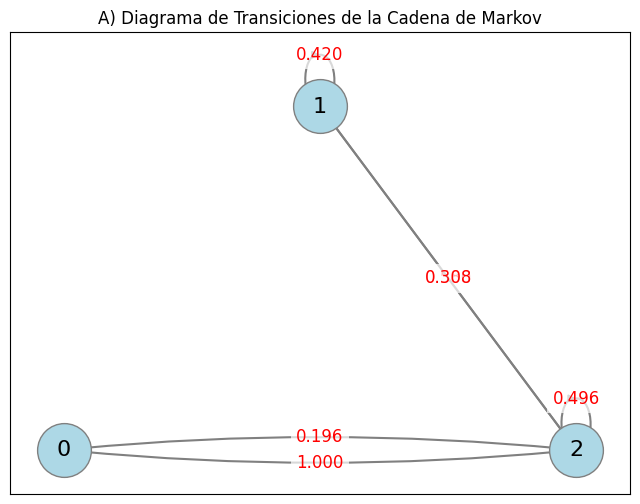



B) Probabilidades Estacionarias (π):
   La cadena de Markov es ergódica.
   π₀ (0 disponibles): 0.1135
   π₁ (1 disponible): 0.3075
   π₂ (2 disponibles): 0.5790
   Suma de π (Verificación): 1.0000


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

## ----------------------------------------------------
## DATOS DEL PROBLEMA
## ----------------------------------------------------
P_MALTRATO = 0.7
P_DEMANDA = {0: 0.4, 1: 0.2, '>=2': 0.4}

## ----------------------------------------------------
## A) CÁLCULO DE LA MATRIZ DE PROBABILIDADES DE TRANSICIÓN (P)
## ----------------------------------------------------

def calcular_matriz_transicion():
    """Calcula la Matriz de Probabilidades de Transición P para E={0, 1, 2}."""
    P = np.zeros((3, 3))

    # ------------------------------------------------
    # TRANSICIONES DESDE i=0 (0 disponibles)
    # Siempre regresa a 2 (los 2 que estaban en mant. salen)
    P[0, 2] = 1.0

    # ------------------------------------------------
    # TRANSICIONES DESDE i=1 (1 disponible)
    # P_arriendo_1 = P(D>=1) = 0.2 + 0.4 = 0.6
    P_arriendo_1 = P_DEMANDA[1] + P_DEMANDA['>=2']

    # P[1, 2] = P(D=0) + P(D>=1) * P(No Maltrato)
    P_1_2_D0 = P_DEMANDA[0] * 1.0 # 0.4
    P_1_2_NoM = P_arriendo_1 * (1 - P_MALTRATO) # 0.6 * 0.3 = 0.18
    P[1, 2] = P_1_2_D0 + P_1_2_NoM # 0.58

    # P[1, 1] = P(D>=1) * P(Maltrato)
    P_1_1_M = P_arriendo_1 * P_MALTRATO # 0.6 * 0.7 = 0.42
    P[1, 1] = P_1_1_M

    # ------------------------------------------------
    # TRANSICIONES DESDE i=2 (2 disponibles)

    # Probabilidad de k maltratos de 2 arriendos (Binomial(n=2, p=0.7))
    P_0_maltratos = (1 - P_MALTRATO)**2    # 0.09
    P_1_maltrato  = 2 * P_MALTRATO * (1 - P_MALTRATO) # 0.42
    P_2_maltratos = P_MALTRATO**2          # 0.49

    # P[2, 2] (0 maltratos) = P(D=0) + P(D=1)*P(NoM) + P(D>=2)*P(0M)
    P_2_2_D0 = P_DEMANDA[0] * 1.0 # 0.4
    P_2_2_D1_NoM = P_DEMANDA[1] * (1 - P_MALTRATO) # 0.2 * 0.3 = 0.06
    P_2_2_D2_M0 = P_DEMANDA['>=2'] * P_0_maltratos # 0.4 * 0.09 = 0.036
    P[2, 2] = P_2_2_D0 + P_2_2_D1_NoM + P_2_2_D2_M0 # 0.496

    # P[2, 1] (1 maltrato) = P(D=1)*P(1M) + P(D>=2)*P(1M)
    P_2_1_D1_M = P_DEMANDA[1] * P_MALTRATO # 0.2 * 0.7 = 0.14
    P_2_1_D2_M1 = P_DEMANDA['>=2'] * P_1_maltrato # 0.4 * 0.42 = 0.168
    P[2, 1] = P_2_1_D1_M + P_2_1_D2_M1 # 0.308

    # P[2, 0] (2 maltratos) = P(D>=2)*P(2M)
    P_2_0_D2_M2 = P_DEMANDA['>=2'] * P_2_maltratos # 0.4 * 0.49 = 0.196
    P[2, 0] = P_2_0_D2_M2

    return P

## ----------------------------------------------------
## B) CÁLCULO DE LAS PROBABILIDADES ESTACIONARIAS (π)
## ----------------------------------------------------

def calcular_probabilidades_estacionarias(P):
    """Calcula las probabilidades estacionarias pi resolviendo pi * P = pi."""

    # P^T - I, para resolver (P^T - I) * pi^T = 0
    A = P.T - np.identity(3)

    # Reemplazamos la última fila por la condición de normalización (suma(pi) = 1)
    A[-1, :] = 1.0

    # Vector de términos independientes (0 para balance, 1 para normalización)
    b = np.zeros(3)
    b[-1] = 1.0

    # Resolver el sistema de ecuaciones lineales A * pi^T = b
    pi = np.linalg.solve(A, b)

    return pi

## ----------------------------------------------------
## VISUALIZACIÓN (Gráfico de la Cadena de Markov)
## ----------------------------------------------------

def graficar_cadena_markov(P):
    """Genera una gráfica del diagrama de transiciones."""
    G = nx.MultiDiGraph()
    estados = [0, 1, 2]
    G.add_nodes_from(estados)

    pos = {0: (0, 0), 1: (1, 1), 2: (2, 0)} # Posiciones fijas

    # Añadir aristas
    for i in estados:
        for j in estados:
            prob = P[i, j]
            if prob > 0:
                etiqueta = f"{prob:.3f}"
                G.add_edge(i, j, weight=prob, label=etiqueta)

    plt.figure(figsize=(8, 6))

    # Dibujar nodos, etiquetas y aristas
    nx.draw_networkx_nodes(G, pos, node_size=1500, node_color='lightblue', edgecolors='gray')
    nx.draw_networkx_labels(G, pos, font_size=16)

    for u, v, data in G.edges(data=True):
        # Configurar curvatura para evitar solapamiento (bucles y aristas 0<->2)
        if u == v: # Bucle
            rad = 0.2
        elif (u, v) == (0, 2) or (u, v) == (2, 0):
            rad = 0.05
        else:
            rad = 0

        nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], arrowstyle='-|>',
                               connectionstyle=f'arc3, rad = {rad}',
                               edge_color='gray', width=1.5,
                               arrows=True)

        # Etiquetas de las probabilidades
        nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): data['label']},
                                     label_pos=0.5, font_color='red', font_size=12,
                                     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
                                     rotate=False,
                                     connectionstyle=f'arc3, rad = {rad}')


    plt.title("A) Diagrama de Transiciones de la Cadena de Markov")
    plt.show()

## ----------------------------------------------------
## FUNCIÓN PRINCIPAL DE RESOLUCIÓN
## ----------------------------------------------------

def resolver_problema_ferrari():
    P = calcular_matriz_transicion()
    pi = calcular_probabilidades_estacionarias(P)

    print("--- Problema del Rey Arturo y los Ferraris (A y B) ---")

    # =======================================================
    # A) Matriz de Transición y Diagrama
    # =======================================================
    print("\n")
    print("A) Matriz de Probabilidades de Transición (P):")
    print("   Estados: 0 (0 disponibles), 1 (1 disponible), 2 (2 disponibles)")
    print(np.round(P, 3))

    graficar_cadena_markov(P)

    # =======================================================
    # B) Probabilidades Estacionarias
    # =======================================================
    print("\n")
    print("B) Probabilidades Estacionarias (π):")
    print("   La cadena de Markov es ergódica.")
    print(f"   π₀ (0 disponibles): {pi[0]:.4f}")
    print(f"   π₁ (1 disponible): {pi[1]:.4f}")
    print(f"   π₂ (2 disponibles): {pi[2]:.4f}")
    print(f"   Suma de π (Verificación): {np.sum(pi):.4f}")


# Ejecutar la función principal
if __name__ == "__main__":
    resolver_problema_ferrari()